# MLflow Experiment Tracking

This notebook provides an interface to view, analyze, and visualize MLflow experiment tracking results directly in Jupyter.

In [4]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for pandas to show more columns/rows
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Set MLflow Tracking URI
Set the tracking URI if your tracking server is remote. If local, it defaults to `./mlruns`.

In [5]:
# mlflow.set_tracking_uri("http://localhost:5000") # Uncomment and modify if using a remote tracking server
client = mlflow.tracking.MlflowClient()

## List All Experiments

In [6]:
experiments = client.search_experiments()
exp_data = []
for exp in experiments:
    exp_data.append({
        "Experiment ID": exp.experiment_id,
        "Name": exp.name,
        "Artifact Location": exp.artifact_location,
        "Lifecycle Stage": exp.lifecycle_stage
    })

experiments_df = pd.DataFrame(exp_data)
display(experiments_df)

,Experiment ID,Name,Artifact Location,Lifecycle Stage
0,1,Home Credit Default Risk,file:d:/MLPs/Home Credit Defaut Risk Predictor...,active
1,0,Default,mlflow-artifacts:/0,active


## View Runs for an Experiment
Replace `experiment_ids` with the ID of the experiment you want to view.

In [7]:
if not experiments_df.empty:
    # Get the ID of the first experiment or specify a specific one
    experiment_id = experiments_df.iloc[0]["Experiment ID"]
    print(f"Fetching runs for experiment ID: {experiment_id}")
    
    runs = mlflow.search_runs(experiment_ids=[experiment_id])
    
    if not runs.empty:
        # Display the most recent runs
        display(runs.head())
    else:
        print("No runs found for this experiment.")
else:
    print("No experiments found.")

Fetching runs for experiment ID: 1


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.opt_accuracy,metrics.best_threshold,metrics.opt_recall,metrics.opt_precision,metrics.roc_auc,metrics.opt_f1_score,params.colsample_bytree,params.gamma,params.eval_metric,params.scale_pos_weight,params.random_state,params.learning_rate,params.max_depth,params.n_estimators,params.min_child_weight,params.subsample,params.scaler,tags.mlflow.source.type,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName
0,2c4e2fdc19d84279ac19aa65433e8751,1,FINISHED,file:d:/MLPs/Home Credit Defaut Risk Predictor...,2026-06-09 17:49:34.203000+00:00,2026-06-09 17:50:06.462000+00:00,0.723087,0.368878,0.664854,0.176827,0.763286,0.279355,0.8853,1.5216,auc,6.1089,42,0.0675,5,114,1,0.7757,None,NOTEBOOK,admin,09_mlflow_logging.ipynb,Final_Tuned_XGBoost
1,3bf7ff353cc74c49839d2b17e35f5c16,1,FINISHED,file:d:/MLPs/Home Credit Defaut Risk Predictor...,2026-06-09 17:34:21.946000+00:00,2026-06-09 17:34:50.680000+00:00,0.721314,0.367778,0.664653,0.175766,0.762457,0.278012,0.8853,1.5216,auc,6.1089,42,0.0675,5,114,1,0.7757,StandardScaler,NOTEBOOK,admin,09_mlflow_logging.ipynb,Final_Tuned_XGBoost


## Plot Metrics
Visualize parameters vs metrics if runs exist.

Available metrics: ['metrics.opt_accuracy', 'metrics.best_threshold', 'metrics.opt_recall', 'metrics.opt_precision', 'metrics.roc_auc', 'metrics.opt_f1_score']
Available parameters: ['params.colsample_bytree', 'params.gamma', 'params.eval_metric', 'params.scale_pos_weight', 'params.random_state', 'params.learning_rate', 'params.max_depth', 'params.n_estimators', 'params.min_child_weight', 'params.subsample', 'params.scaler']


C:\Users\admin\AppData\Local\Temp\ipykernel_7264\3587054337.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  runs[x_col] = pd.to_numeric(runs[x_col], errors='ignore')


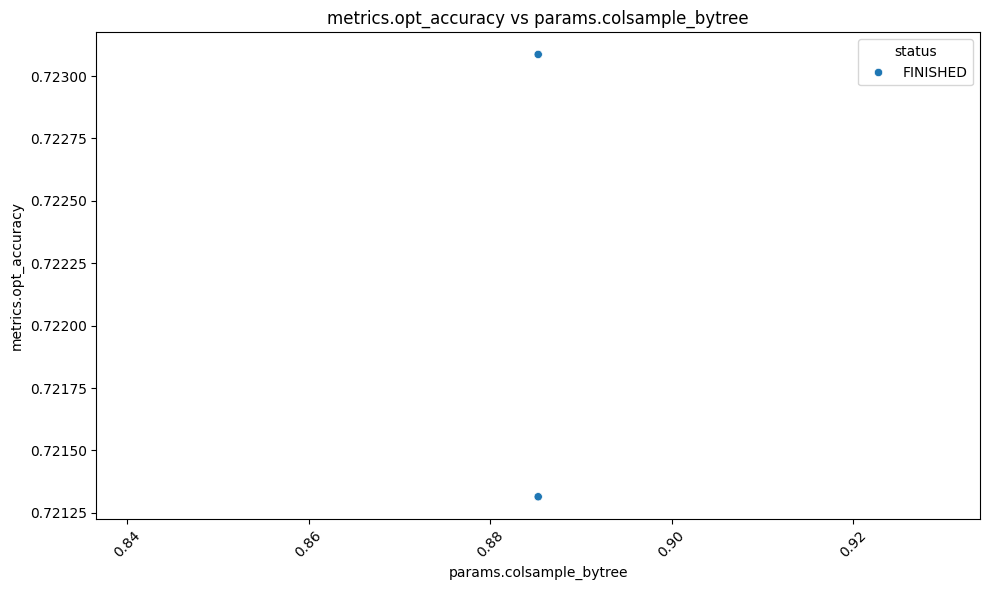

In [8]:
if not experiments_df.empty and 'runs' in locals() and not runs.empty:
    # Filter to only get metrics and parameters columns
    metrics_cols = [c for c in runs.columns if c.startswith('metrics.')]
    params_cols = [c for c in runs.columns if c.startswith('params.')]
    
    if metrics_cols and params_cols:
        print(f"Available metrics: {metrics_cols}")
        print(f"Available parameters: {params_cols}")
        
        # Example: Plot first parameter vs first metric
        x_col = params_cols[0]
        y_col = metrics_cols[0]
        
        # Convert parameter to numeric if possible for plotting
        runs[x_col] = pd.to_numeric(runs[x_col], errors='ignore')
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=runs, x=x_col, y=y_col, hue='status')
        plt.title(f'{y_col} vs {x_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough metrics or parameters logged to plot.")
else:
    print("No data to plot.")

## Best Runs Analysis
Find and display the best run based on a specific metric.

In [9]:
if not experiments_df.empty and 'runs' in locals() and not runs.empty and metrics_cols:
    # Choose the first metric as target for optimization
    target_metric = metrics_cols[0]
    
    # Sort runs by target metric (assuming higher is better; use ascending=True if lower is better)
    best_runs = runs.sort_values(by=target_metric, ascending=False)
    
    print(f"Top 5 runs by {target_metric}:")
    display(best_runs[['run_id', 'status', target_metric] + params_cols].head())
else:
    print("No metric data available to analyze best runs.")

Top 5 runs by metrics.opt_accuracy:


,run_id,status,metrics.opt_accuracy,params.colsample_bytree,params.gamma,params.eval_metric,params.scale_pos_weight,params.random_state,params.learning_rate,params.max_depth,params.n_estimators,params.min_child_weight,params.subsample,params.scaler
0,2c4e2fdc19d84279ac19aa65433e8751,FINISHED,0.723087,0.8853,1.5216,auc,6.1089,42,0.0675,5,114,1,0.7757,None
1,3bf7ff353cc74c49839d2b17e35f5c16,FINISHED,0.721314,0.8853,1.5216,auc,6.1089,42,0.0675,5,114,1,0.7757,StandardScaler


## Launch MLflow UI
Run this command in your terminal to start the MLflow tracking UI:

```bash
mlflow ui
```

Then open `http://127.0.0.1:5000` in your browser to view the interactive dashboard.